# N1 · 时空 vs 逐帧视频扩散 (时序连贯从哪来)

> 配套 13.4-L1 · 用「运动轨迹」当视频 (一段视频 = 一个 2D 点在 T 帧的轨迹)。
> 训两个扩散模型: 时空 (joint, 帧互相 attend) vs 逐帧 (per-frame, 独立)。
> 亲手看到: **时序连贯来自联合建模时间, 不是免费的**。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import numpy as np, torch
import video_diffusion as vd
print('video_diffusion 就绪, 每段视频', vd.T_FRAMES, '帧')

video_diffusion 就绪, 每段视频 12 帧


## 1. 视频数据 = 平滑运动轨迹. 扩散要学会生成连贯的运动

视频数据: (400, 12, 2) (400 条轨迹, 每条 12 帧, 每帧 2D)


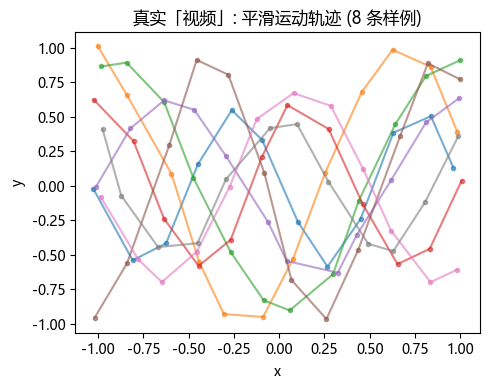

真实轨迹帧间跳变 (连贯基准): 0.450


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
data = vd.make_trajectories(n=400, seed=1)
print('视频数据:', data.shape, '(400 条轨迹, 每条', vd.T_FRAMES, '帧, 每帧 2D)')
fig, ax = plt.subplots(figsize=(5,4))
for i in range(8):
    ax.plot(data[i,:,0], data[i,:,1], '-o', ms=3, alpha=0.6)
ax.set_title('真实「视频」: 平滑运动轨迹 (8 条样例)'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()
print(f'真实轨迹帧间跳变 (连贯基准): {vd.temporal_coherence(data):.3f}')

## 2. 训练两个视频扩散模型
- **时空 (joint)**: transformer 把 T 帧当 token 序列, 帧之间互相 attend (L1 正解)
- **逐帧 (per-frame)**: MLP 每帧独立去噪, 不看其它帧 (L1 反例)

In [3]:
torch.manual_seed(0)
models = {}
for joint in [True, False]:
    m = vd.build_video_denoiser(joint=joint, seed=0)
    losses, sched = vd.train_video(m, data, epochs=500, seed=0)
    models[joint] = (m, sched, losses)
    tag = '时空(joint)' if joint else '逐帧(per-frame)'
    print(f'{tag:18} 训练 loss {losses[0]:.3f} → {losses[-1]:.3f}')

时空(joint)          训练 loss 1.479 → 0.132


逐帧(per-frame)      训练 loss 0.995 → 0.261


## 3. 各生成 100 条轨迹, 看连贯性 (帧间跳变越小越连贯)

C:\Users\ericp\AppData\Local\Temp\ipykernel_8340\2026700098.py:17: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  plt.suptitle(f'生成的「视频」轨迹 (真实基准 {real_coh:.3f})'); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Temp\ipykernel_8340\2026700098.py:17: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Microsoft YaHei.
  plt.suptitle(f'生成的「视频」轨迹 (真实基准 {real_coh:.3f})'); plt.tight_layout(); plt.show()
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


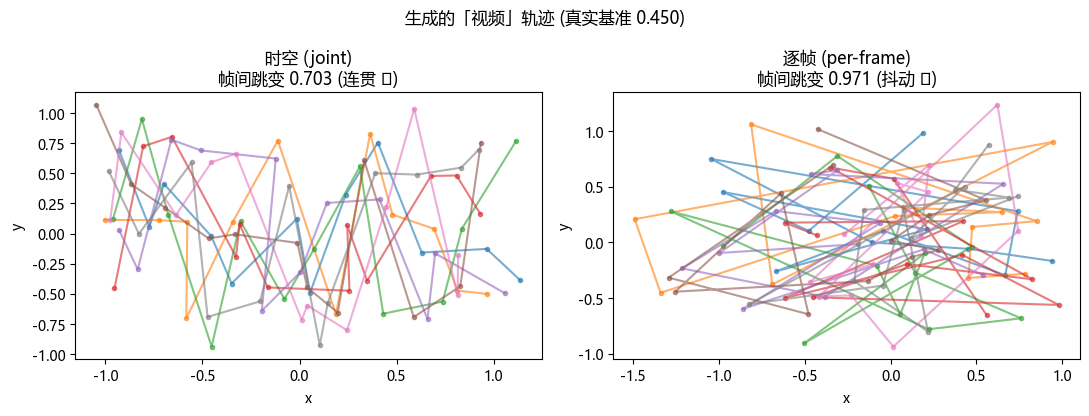

→ 时空模型生成平滑连贯轨迹; 逐帧模型抖动 (帧间乱跳)。


In [4]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
real_coh = vd.temporal_coherence(data)
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
for ax, joint in zip(axes, [True, False]):
    m, sched, _ = models[joint]
    gen = vd.sample_videos(m, sched, n=100, seed=2)
    coh = vd.temporal_coherence(gen)
    for i in range(8):
        ax.plot(gen[i,:,0], gen[i,:,1], '-o', ms=3, alpha=0.6)
    tag = '时空 (joint)' if joint else '逐帧 (per-frame)'
    verdict = '连贯 ✅' if coh < real_coh*1.8 else '抖动 ⚠'
    ax.set_title(f'{tag}\n帧间跳变 {coh:.3f} ({verdict})'); ax.set_xlabel('x'); ax.set_ylabel('y')
plt.suptitle(f'生成的「视频」轨迹 (真实基准 {real_coh:.3f})'); plt.tight_layout(); plt.show()
print('→ 时空模型生成平滑连贯轨迹; 逐帧模型抖动 (帧间乱跳)。')

## 4. 反思
你亲手验证了视频扩散的核心: **时序连贯来自联合建模时间**。带走:
- 同样的 DDPM 框架 (M13.1), 数据从「2D 点」变成「T 帧轨迹」, 去噪网络从 MLP 变成时空 transformer。
- **逐帧独立 → 抖动; 时空联合 (帧互相 attend) → 连贯**。连贯不是免费的, 来自跨帧建模。
- 真实视频 (Sora) 是同一个东西的放大版: 把「2D 点」换成「时空 latent patch」(N1→L2)。
下一步 N2: 把「连贯」量化成度量, 并体会长程一致比帧间更难 (L3)。